In [ ]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "models").is_dir() and (path / "datasets").is_dir() and (path / "utils").is_dir():
            return path
    raise RuntimeError("Repository root was not found from the current working directory.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) in sys.path:
    sys.path.remove(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

print("repo root:", REPO_ROOT)


In [2]:
from utils.visualization import show_result
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

import config_mv
import config_visa
from models.patchcore import PatchCore
from models.backbone import get_backbone
from datasets.mvtec import MyData
from datasets.visa import ViSA
from utils.metrics import get_image_auc
from utils.visualization import show_result, denormalize

In [3]:
if torch.cuda.is_available():
    device = 'cuda' 
elif torch.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

mps


In [4]:
train_data = ViSA(
    config_visa.CLASS_NAME,
    phase="Normal",
    batch_size = config_visa.BATCH_SIZE,
    shuffle=False,
    limit = config_visa.TRAIN_LIMIT,
)

test_data = ViSA(
    config_visa.CLASS_NAME,
    phase = "Anomaly",
    batch_size = config_visa.BATCH_SIZE,
    shuffle = False,
    limit = config_visa.TRAIN_LIMIT,
)

In [5]:
backbone = get_backbone()
model = PatchCore(backbone, k = config_visa.K, device = device)

model.fit(train_data)

In [6]:
scores = []
heatmaps = []
imgs = []
for img, label in test_data:
    score, heatmap = model.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

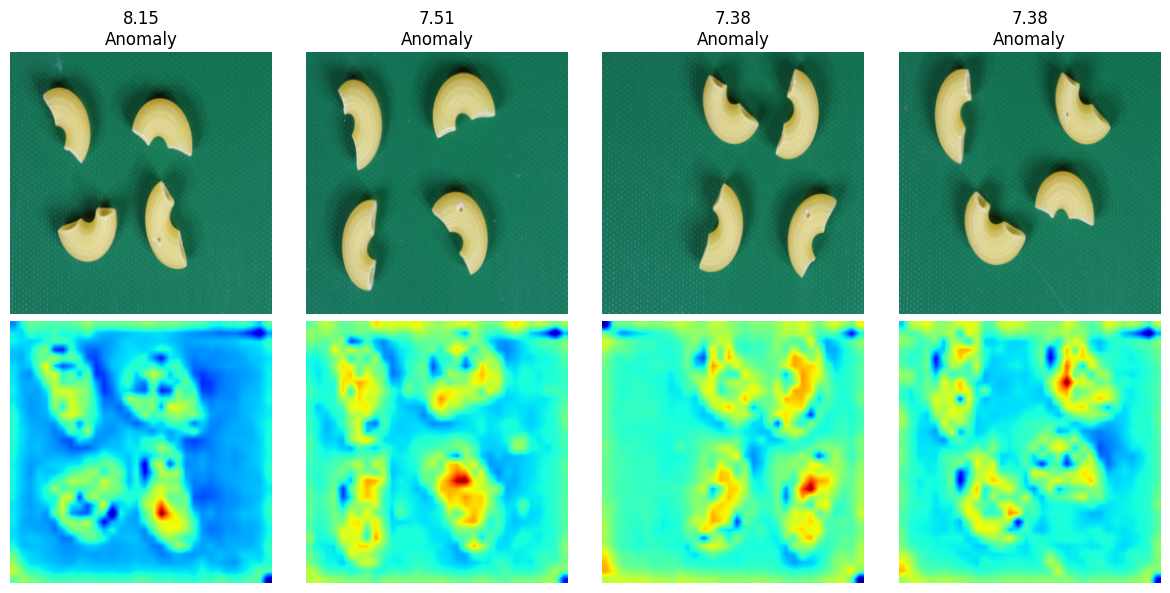

In [7]:
show_result(test_data, scores, heatmaps, k=4)